# **LAB2 APAI: DNN Definition & Training**

**Credits**: *Călin Diaconu, Davide Nadalini, Ilenia Carboni, Alberto Dequino, Luca Bompani, Lorenzo Lamberti, Francesco Conti*
*(University of Bologna)*

**Contacts**: *calin.diaconu2@unibo.it, alberto.dequino@unibo.it, seyedahmad.mirsalar2@unibo.it, ihor.sachok@unibo.it*



## **In this Hands-on session:**

A first-time user of the PyTorch framework will learn how to define, train, and test a neural network over the Fashion-MNIST dataset.

### Tasks:

---

1. Creating a model
2. Count network's parameters and MAC operations
3. Dataset & DataLoaders
4. Testing the CNN over the dataset
5. Training loop
6. Save/load model
---




## Let's start!

Let us start by installing dependencies...

**Note:** if you need to install more packages, add them here! (but remember to also import them afterwards!)

In [ ]:
#@title Install dependencies { form-width: "20%" }

# these ones should already be available
!pip install numpy
!pip install tqdm
!pip install pillow

!pip install torch
!pip install torchvision

!pip install thop
!pip install matplotlib
!pip install scikit-learn
!pip install torchinfo

# You will need these if running on a private server (no colab)
# !pip install jupyter
# !pip install ipywidgets
# !jupyter nbextension enable --py widgetsnbextension



## Imports:
Now we import some packages we will need:

In [ ]:
#basic
import os
from os.path import join
import numpy as np
from tqdm import tqdm
import time

#plotting
import matplotlib.pyplot as plt

#torch
import torch; print('\nPyTorch version in use:', torch.__version__, '\ncuda avail: ', torch.cuda.is_available())
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

#torchvision
import torchvision
from torchvision import transforms, datasets

# others
from copy import deepcopy
from tqdm.autonotebook import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import inspect


## Set device
Between "cuda" and "cpu"

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device: %s' % device)

# **Task 1:** Creating a model

### The first real step is to define the network topology. We will define a custom one.

---



* Use [`torch.nn.Module`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html)
* Follow in-code hints
* **IMPORTANT:** Instantiate a separate [`torch.nn.Module`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html) for each node in your topology; this is mandatory for parametric modules (e.g., [`torch.nn.Conv2d`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Conv2d.html), [`nn.Linear`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Linear.html), [`nn.BatchNorm2d`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.BatchNorm2d.html)).
* **Note**: set the padding of each Convolution to 1 to keep the size of the output feature map!

---

**Resources**:
* [`torch.nn` documentation](https://docs.pytorch.org/docs/2.14/nn.html)
* [Official PyTorch tutorials and documentation](https://pytorch.org/tutorials/beginner/basics/intro.html)
* [PyTorch tutorial: how to define a NN](https://pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html)

---

You can use the following modules (click on each for its documentation):
* [`nn.Conv2d`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Conv2d.html)
* [`nn.BatchNorm2d`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.BatchNorm2d.html)
* [`nn.ReLU`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.ReLU.html)
* [`nn.MaxPool2d`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.MaxPool2d.html)
* [`nn.Flatten`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.modules.flatten.Flatten.html)
* [`nn.Linear`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Linear.html) (the Fully Connected layer)
* [`nn.LogSoftmax`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.LogSoftmax.html)



**You must define the NN topology following this diagram:**

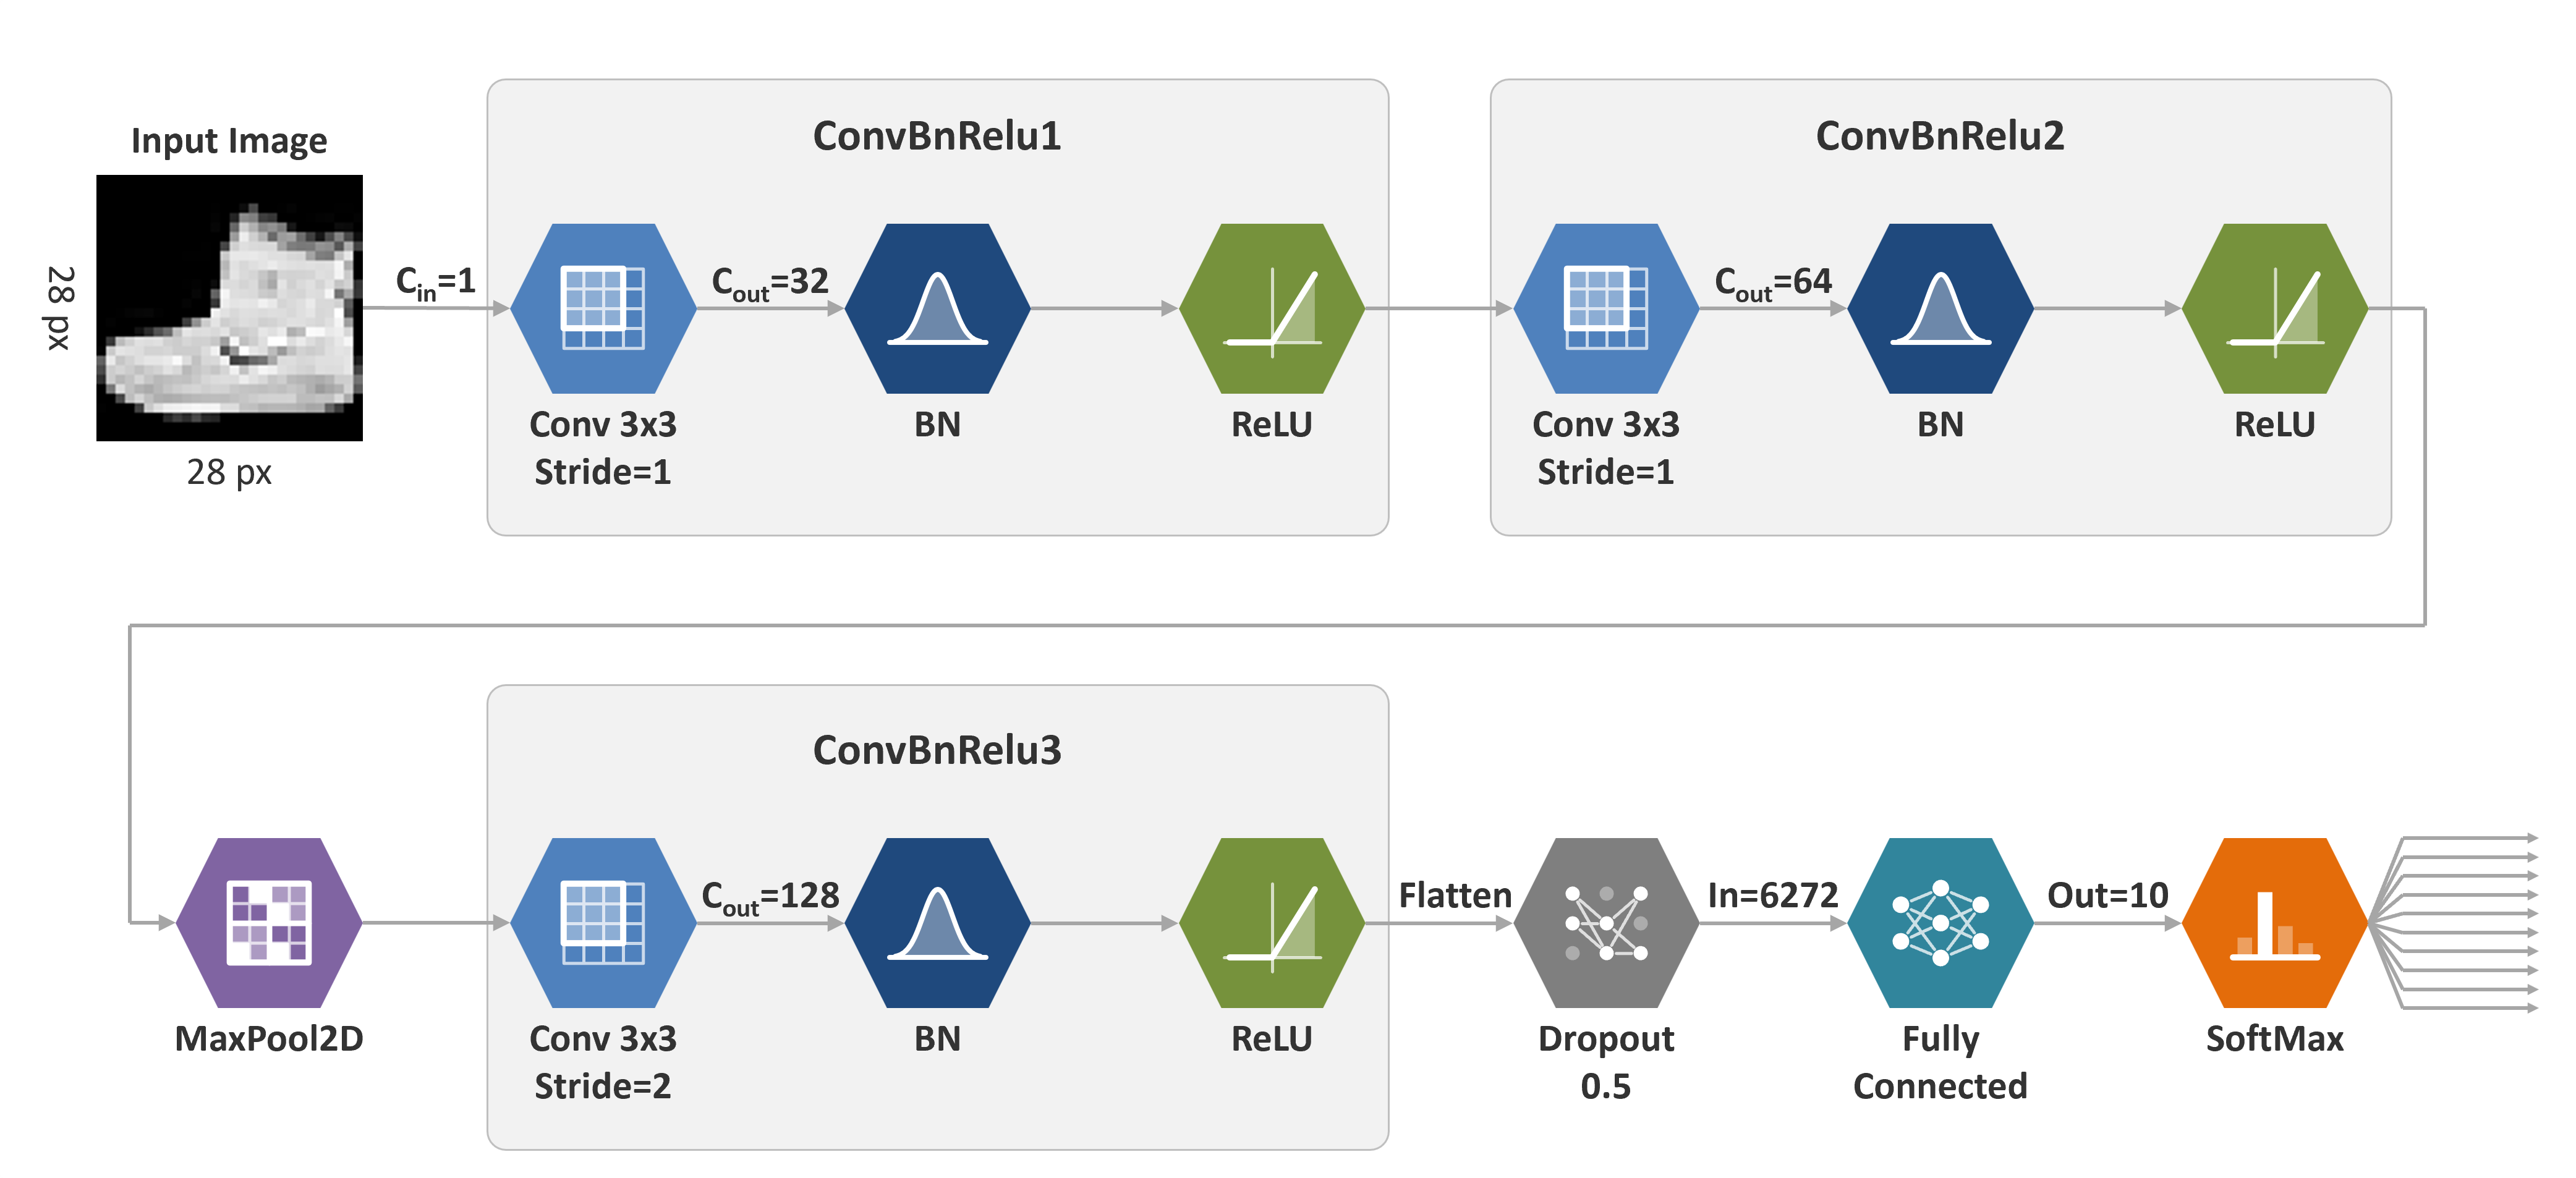

In [ ]:
class CNN(nn.Module):
    def __init__(self, n_classes=10, depth_mult=1.):
        super(CNN, self).__init__()

        # YOUR CODE HERE, e.g.:
        # self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=3, stride=1, padding=1)
        # self.conv2 = ...
        # ...

    def forward(self, x):
        # YOUR CODE HERE, e.g.:
        # output = self.conv1(x)
        # output = self.bn1(output)
        # ...

        return output

net = CNN().to(device)


### Test defined network, and verify layers

In [ ]:
input_size = (1, 1, 28, 28) 
input = torch.randn(input_size).to(device)

Perform a test forward pass, and print output tensor size together with the CNN network topology defined:

In [ ]:
output = net(input)

print('Expected output shape: (1, 10)')
print('Actual output shape:', output.shape)
print('Network Topology:\n',net)

# **Task 2:** Count network's parameters and MAC operations

### Calculate the number of parameters of the model. Calculate the Multiply-Accumulate operations (MACs). You can use some external pre-implemented functions from GitHub (see Resources below).

We will define a function to measure the model's MAC operations and number of parameters.

---

**Resources**:
* [PyTorch Info (`torchinfo`)](https://github.com/TylerYep/torchinfo)
* [PyTorch Operations counter (`thop`)](https://github.com/Lyken17/pytorch-OpCounter)
* [PyTorch FLOPs counter (`ptflops`)](https://github.com/sovrasov/flops-counter.pytorch)

---

**TorchInfo insights:**
This tool calculates the parameters size as (number_of_parameters*4).
This is because each parameter needs 4 bytes (32 bits) to be represented in float32 format.

In [ ]:
def network_size_and_mac(net, input_size, verbose=False):
    # calculate here the number of parameters (params) and MACs (macs) of the network

    # params = YOUR CODE HERE
    # macs = YOUR CODE HERE

    print("Number of parameters: %.3fk \tMAC: %.3fM\n" % (params/1e3, macs/1e6))

test_net = CNN().to(device)
network_size_and_mac(test_net, input_size)  # use a fresh network, since some counters (e.g., thop) modify the model they analyze

# **Task 3:** Dataset & DataLoaders

### Create the datasets and data loaders for Fashion-MNIST, for both the training and validation sets.

---

In this notebook we'll train a custom CNN on the [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist), which is a set of 28x28 grayscale images of clothes.
This dataset is provided by the [Torchvision package](https://docs.pytorch.org/vision/stable/index.html).

Before diving in, let's look at the Fashion-MNIST dataset. The dataset has 60k training images and 10k validation images. It has a total of 10 classes, each represented by an integer index. The following cell creates a mapping from these indices to their corresponding human-readable strings, then downloads the Fashion-MNIST training dataset from Torchvision. It may take a minute to run.

Torchvision provides easy access to many datasets, including COCO, CIFAR, and Cityscapes. See its documentation for a complete list. 

The dataset is stored on the Colab VM in the `/data/fashionmnist` directory.

---

**Resources**:
* [PyTorch quickstart tutorial](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html)
* [PyTorch tutorial: Datasets & DataLoaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)

---

**Sub-tasks**:
* Download Fashion-MNIST using [`torchvision.datasets`](https://docs.pytorch.org/vision/stable/datasets.html)
* Define 2 [transformations](https://docs.pytorch.org/vision/stable/transforms.html) to apply to the dataset: conversion of the data to tensors, and normalization of the input pixel values
* Define the dataset objects
* Define the data loaders with [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/2.14/data.html#torch.utils.data.DataLoader), using a batch size of 128
* Sanity check: you must get 60k training images and 10k validation images

In [ ]:
#@title Show dataset image samples
class_map = {
    0 : "t-shirt",
    1 : "trouser",
    2 : "pullover",
    3 : "dress",
    4 : "coat",
    5 : "sandal",
    6 : "shirt",
    7 : "sneaker",
    8 : "bag",
    9 : "ankle boot"
}

# Downloads the Fashion MNIST dataset using Torchvision
fashion_mnist_dataset = # YOUR CODE HERE (import fashion mnist with: torchvision.datasets.FashionMNIST)

# show one image from dataset
img_index = 0
tup = fashion_mnist_dataset[img_index]  # tup = (image, label)
display(tup[0].resize((224, 224)))
print(class_map[tup[1]])

### Data loaders for Fashion-MNIST

The code below first sets up the transforms using `torchvision.transforms` to convert the images to PyTorch tensors and normalize them.

Next, we use `torchvision.datasets` to download the Fashion-MNIST dataset and apply the transforms defined above:

* `train_dataset` contains the training data
* `valid_dataset` contains the validation data

Finally, we use `torch.utils.data.DataLoader` to build the data loaders for the training and validation sets.

In [ ]:
def get_data_loaders(train_batch_size=128, val_batch_size=128, path='./data/fashionmnist', verbose=False):
    #define data transformations
    fashion_mnist  = datasets.FashionMNIST(download=True, train=True, root=path).data.float()
    data_transform = transforms.Compose([transforms.ToTensor(), 
                                         transforms.Normalize((fashion_mnist.mean()/255,), (fashion_mnist.std()/255,))])  

    # Load train/valid datasets
    train_dataset = # YOUR CODE HERE
    valid_dataset = # YOUR CODE HERE

    # Define dataloaders
    train_loader = # YOUR CODE HERE
    valid_loader = # YOUR CODE HERE

    # Count how many images there are in each set
    # YOUR CODE HERE

    return train_loader, valid_loader

train_loader, val_loader = get_data_loaders(verbose=True)

# **Task 4:** Testing the CNN over the dataset

### We will build a testing loop in order to calculate the accuracy of our NN.

---

**Resources**:
* [PyTorch quickstart tutorial](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html)

---

**Sub-tasks**:
* Define an accuracy metric as `num_correct_predictions/total_n_predictions`
* Write the testing loop in the `validate` function, following the provided skeleton
* Note: remember to set the network to evaluation mode with [`net.eval()`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html#torch.nn.Module.eval)

---

### Accuracy metric calculation

First we define a function to calculate the accuracy, defined as: `accuracy = num_correct_predictions/total_n_predictions`

In [ ]:
def calculate_accuracy(best_guesses, targets):
    num_correct = # YOUR CODE HERE
    total_guesses = # YOUR CODE HERE

    correct_percentage = num_correct/total_guesses
    
    return correct_percentage

### Define the loss function - use cross entropy

Cross entropy works well for multi-class problems

In [ ]:
# Define the loss function
loss_function = # YOUR CODE HERE

### Testing function
Before training we want to verify our data->network pipeline and set a baseline level of performance. The following cell defines a function, `validate`, that runs a network on a dataset and shows the percentage of the dataset that was correctly classified.

In [ ]:
def validate(net, val_loader, loss_function, accuracy_score):
    val_losses = []
    val_accuracy = []
    
    # set net to evaluating (testing)
    net.eval()
    with torch.no_grad():
        for batch_idx, data in enumerate(val_loader):
            inputs, labels = data[0].to(device), data[1].to(device)

            # net forward
            outputs = # YOUR CODE HERE (this gets the prediction from the network)

            # calculate loss
            loss = # YOUR CODE HERE
            val_losses.append(loss.item())  # store the current batch's validation loss, to compute the average below

            # calculate validation accuracy
            predicted_classes = torch.max(outputs, 1)[1] # get class from network's prediction
            val_accuracy.append(calculate_accuracy(predicted_classes.cpu(), labels.cpu())) 
            
    average_val_loss = sum(val_losses)/(batch_idx+1)
    return val_accuracy, average_val_loss

In [ ]:
val_accuracy, average_val_loss = validate(net, val_loader, loss_function, accuracy_score)
print('Accuracy: %0.2f'% (sum(val_accuracy)/len(val_accuracy)))

# **Task 5:** Training loop

### We are now going to train a neural network on the Fashion-MNIST dataset.

---

**Resources**:
* [PyTorch quickstart tutorial](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html)
* [Learning PyTorch with examples](https://pytorch.org/tutorials/beginner/pytorch_with_examples.html)

---

**Sub-tasks**:
* Use the [Cross Entropy](https://docs.pytorch.org/docs/2.14/generated/torch.nn.CrossEntropyLoss.html) `loss_function` already defined in Task 4
* Define an [Adam optimizer](https://docs.pytorch.org/docs/2.14/generated/torch.optim.Adam.html)
* Write the training loop in the `training` function, following the provided skeleton
* Plot the training and validation loss over the epochs: this is a good practice to track the training process

---

**Tips**:
* Use `.to(device)` on both the model and the inputs to train on the GPU, which is much faster than the CPU!
* Use [`net.train()`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html#torch.nn.Module.train) to set the network to training mode before starting the main loop
* Optional: try an [SGD optimizer](https://docs.pytorch.org/docs/2.14/generated/torch.optim.SGD.html) instead (e.g., `torch.optim.SGD(net.parameters(), lr=0.01, momentum=0.9)`) and compare the loss curves

---

In this case we'll use:
* **Loss function:** [CrossEntropyLoss](https://docs.pytorch.org/docs/2.14/generated/torch.nn.CrossEntropyLoss.html), since we have a classification problem
* **Optimizer:** [Adam](https://docs.pytorch.org/docs/2.14/generated/torch.optim.Adam.html), since it converges quickly with its default settings

**Loops:**
* Loop over the epochs: at the end of each epoch we calculate the validation accuracy
* Loop over the training batches: for each batch we backpropagate using the loss function

**Training step:**
* Enumerate the dataset in batches
* Run the network on each batch
* Evaluate the network's performance using the loss function
* Use `optimizer.zero_grad()` to reset the gradients before backpropagation
* Call `backward()` on the loss to propagate the gradients through the network
* Use the optimizer's `step()` to apply the gradients to the network's weights

```
Pseudo-code:
├─ for each epoch:
│  ├── for each training batch:
│  │  ├── output = net(input)
│  │  ├── loss = loss_function(output, ground_truth)
│  │  ├── optimizer.zero_grad()
│  │  ├── loss.backward()
│  │  ├── optimizer.step()
│  │  ├── calculate training accuracy
│  │  └── print: training accuracy and loss
│  └── test on validation set: print accuracy
```

We'll only train for 2 epochs for timeliness. The following cell should take a few minutes to run.

### **Note: why do we need to reset the gradients?**
In PyTorch, for every mini-batch during the training phase, we typically want to explicitly set the gradients to zero (`optimizer.zero_grad()`) before starting backpropagation (i.e., computing the gradients used to update the weights and biases) because PyTorch accumulates the gradients on subsequent backward passes. So, the default action has been set to accumulate (i.e. sum) the gradients on every `loss.backward()` call.

If you don't reset them, the gradient would be a combination of the old gradient, which you have already used to update your model parameters, and the newly-computed gradient. It would therefore point in some other direction than the intended direction towards the minimum (or maximum, in case of maximization objectives).

**In a nutshell:** if you don't clear the gradients, they will accumulate across multiple iterations of training. This can lead to incorrect gradients and slower convergence of the model. Therefore, it's important to clear the gradients before computing the gradients for the current iteration.

Check out: [Why do we need to call `zero_grad()` in PyTorch?](https://saturncloud.io/blog/why-do-we-need-to-call-zerograd-in-pytorch/)


In [ ]:
#@title Training parameters { form-width: "70%" }
epochs = 2 #@param {type:"integer"}
batch_size = 128 #@param {type:"integer"}

In [ ]:
# Move net to gpu:
net.to(device)

# Build Dataloaders
train_loader, val_loader = get_data_loaders(batch_size, batch_size)

def training(net, train_loader, val_loader, loss_function, epochs):    
    # Define optimizer
    optimizer = # YOUR CODE HERE

    # count tot batches
    tot_train_batches = len(train_loader)
    tot_val_batches = len(val_loader)

    # Create lists to store training history
    train_loss_history = []
    train_accuracy_history = []

    # Create lists to store validation history
    val_loss_history = []
    val_accuracy_history = []

    start_ts = time.time()     

    # ----------------- TRAINING  -------------------- #
    # loop for every epoch (training + evaluation)
    for epoch in range(epochs):
        total_epoch_loss = 0
        train_accuracy = []

        net.train() # set model to training
        # loop for every batch of images in the dataset
        for batch_idx, data in enumerate(train_loader):
            inputs, labels = data[0].to(device), data[1].to(device)
            
            # Compute prediction (forward input in the model)
            outputs = # YOUR CODE HERE

            # Compute prediction error with the loss function
            loss = # YOUR CODE HERE

            # Gradients to zero for every batch of data
            optimizer.# YOUR CODE HERE

            # Backpropagation
            # YOUR CODE HERE

            # Optimizer step
            # YOUR CODE HERE
            
            # Getting training quality data
            current_loss = loss.item()

            # Compute average loss
            total_epoch_loss += current_loss
            average_train_loss = total_epoch_loss/(batch_idx+1)
            
            # Calculate training accuracy
            predicted_classes = torch.max(outputs, 1)[1] # get class from network's prediction
            train_accuracy.append(calculate_accuracy(predicted_classes.cpu(), labels.cpu())) 

            average_train_accuracy = sum(train_accuracy)/(batch_idx+1)
            

        # ----------------- VALIDATION  ----------------- #
        val_accuracy, average_val_loss = # YOUR CODE HERE

        # compute mean accuracy
        average_train_accuracy = sum(train_accuracy)/tot_train_batches
        average_val_accuracy = sum(val_accuracy)/tot_val_batches

        # print training/validation Accuracy and Loss
        print('Epoch %d/%d' % (epoch+1,epochs), 'Training loss:  %.4f' % (average_train_loss), 'Accuracy: %.4f' % (average_train_accuracy))
        print('Validation Loss: %.4f' % (average_val_loss), 'Accuracy: %.4f' % (average_val_accuracy))

        # append current average training loss to a buffer variable, for plotting learning curve later
        train_loss_history.append(float(average_train_loss))
        val_loss_history.append(float(average_val_loss))
        train_accuracy_history.append(float(average_train_accuracy))
        val_accuracy_history.append(float(average_val_accuracy))

    print('Training time: %.1f seconds' % (time.time()-start_ts)) 

    return train_loss_history, train_accuracy_history, val_loss_history, val_accuracy_history



In [ ]:
(train_loss_history,
train_accuracy_history, 
val_loss_history, 
val_accuracy_history) = training(net, train_loader, val_loader, loss_function, epochs)

We now re-evaluate our network's performance, and you should see an accuracy ~90%

### Plot training/validation loss
This is a good practice to track the training process.

In [ ]:
plt.plot(
    # YOUR CODE HERE
    label="Training Loss")

plt.plot(
    # YOUR CODE HERE
    label="Validation Loss")

plt.xlabel('No. of Epochs')
plt.ylabel('Loss')

plt.legend(frameon=False)
plt.show()

In [ ]:
plt.plot(
    # YOUR CODE HERE
    label="Training Accuracy")

plt.plot(
    # YOUR CODE HERE
    label="Validation Accuracy")

plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')

plt.ylim([0., 1.]) # limit y axis between 0 and 1
plt.legend(frameon=False)
plt.show()

# **Task 6:** Save/load model

### You must be able to save and load your model correctly, as you will use it in future LAB sessions.

---

**Resources**:
* [PyTorch tutorial: Save and load the model](https://pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html)

---

**Sub-tasks**:
* Save the current model's weights in the `save_net` function (see [`torch.save`](https://docs.pytorch.org/docs/2.14/generated/torch.save.html))
* Load the pre-trained weights into a new, non-initialized instance of the network in the `load_net` function (see [`torch.load`](https://docs.pytorch.org/docs/2.14/generated/torch.load.html) and [`load_state_dict`](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html#torch.nn.Module.load_state_dict))
* Use the `validate` function from Task 4 to test the new model with the pre-trained weights: you should get ~90% accuracy again

---

**Tips**:
* Save the weights with `net.state_dict()`, not the whole model: recent PyTorch versions load files with `weights_only=True` by default, so a whole pickled model will fail to load

---



In [ ]:
#@title Export parameters { form-width: "70%" }
model_export_path = "./model/" #@param {type:"string"}
model_name = 'ExampleNet.pth' #@param {type:"string"}
os.makedirs(model_export_path, exist_ok=True)


### Save a PyTorch model

In [ ]:
#Save Pytorch model
def save_net(net,model_path, model_name):
    #Save Pytorch model
    # YOUR CODE HERE
       
save_net(net,model_export_path, model_name)

### Load a PyTorch model

In [ ]:
NEW_net = CNN().to(device)

# Load a PyTorch Model
def load_net(net, model_path, model_name, device):
    ''' Load a PyTorch Model '''
    checkpoint_file= join(model_path,model_name)

    # Load the weights file
    state_dict = # YOUR CODE HERE

    # Load weights into the network
    # YOUR CODE HERE

    # Move the network to device (CPU or GPU)
    net.to(device)
    return net

NEW_net = load_net(NEW_net, model_export_path, model_name, device)

Test the network accuracy again, to make sure that you saved/loaded the weights correctly. You should get ~90% accuracy again.

In [ ]:
# Test over validation dataset
val_accuracy, average_val_loss = validate(NEW_net, val_loader, loss_function, accuracy_score)

# Print validation statistics
# YOUR CODE HERE